# Housing Price Prediction using ML

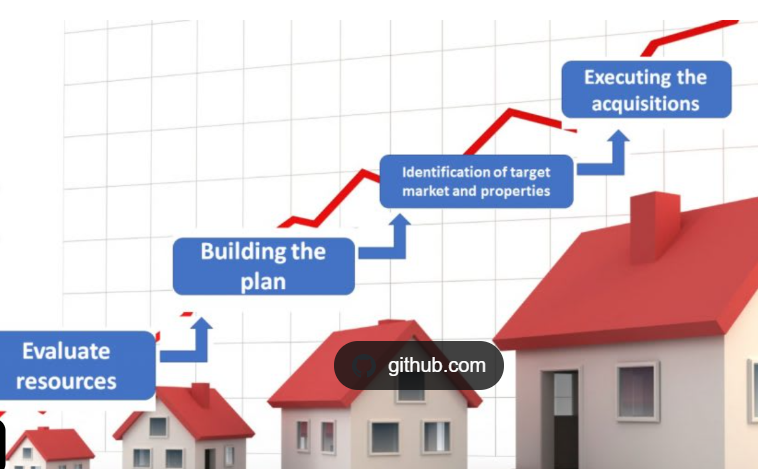

# Step 1 : Load Important Modules

In [4]:
import pandas as  pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import pickle
import os
import time


# Step 2  :Load Data

In [5]:
housing = fetch_california_housing()

In [6]:
df = pd.DataFrame(housing.data, columns = housing.feature_names)

df["MedHouseVal"] = housing.target

In [7]:
housing.target_names

['MedHouseVal']

In [8]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Step 3 : Exploratory Data Analysis

In [9]:
# Check shape
print(df.shape)

# Print number of rows
print("No of Rows:", df.shape[0])

# Print number of columns
print("No of Columns:", df.shape[1])



(20640, 9)
No of Rows: 20640
No of Columns: 9


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [14]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [15]:
len(df.columns)

9

In [19]:


# Plot histograms for all numeric columns in one grid
df.hist(figsize=(15,10), bins=30, color="skyblue", edgecolor="black")
plt.suptitle("Histograms of California Housing Features", fontsize=16)
plt.show()

C:\Users\prose\AppData\Local\Temp\ipykernel_24504\2345680638.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [18]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [20]:
sns.heatmap(df.corr(), annot = True)

<Axes: title={'center': 'MedHouseVal'}>

# Step 4 :Data Preprocessing

In [21]:
 x = df.iloc[ : , : -2 ]

In [22]:
x.head(1)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88


In [23]:
y = df.iloc [ : , -1]

In [24]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

# Data StandardScaler

In [25]:
scl = MinMaxScaler()

In [26]:
 scaled_x=scl.fit_transform(x)

In [27]:
scaled_x

array([[0.53966842, 0.78431373, 0.0435123 , ..., 0.00894083, 0.00149943,
        0.5674814 ],
       [0.53802706, 0.39215686, 0.03822395, ..., 0.0672104 , 0.00114074,
        0.565356  ],
       [0.46602805, 1.        , 0.05275646, ..., 0.01381765, 0.00169796,
        0.5642933 ],
       ...,
       [0.08276438, 0.31372549, 0.03090386, ..., 0.0281398 , 0.0013144 ,
        0.73219979],
       [0.09429525, 0.33333333, 0.03178269, ..., 0.02068444, 0.0011515 ,
        0.73219979],
       [0.13025338, 0.29411765, 0.03125246, ..., 0.03879032, 0.00154886,
        0.72582359]], shape=(20640, 7))

In [28]:
scaled_df = pd.DataFrame(scaled_x, columns = x.columns)

In [29]:
scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293


In [30]:
scaled_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,0.232464,0.541951,0.032488,0.022629,0.039869,0.001914,0.328572
std,0.131020,0.246776,0.017539,0.014049,0.031740,0.008358,0.226988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142308,0.333333,0.025482,0.019943,0.021974,0.001398,0.147715
50%,0.209301,0.549020,0.031071,0.021209,0.032596,0.001711,0.182784
75%,0.292641,0.705882,0.036907,0.022713,0.048264,0.002084,0.549416
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Step 5 : Data spliting

In [31]:
x_train, x_test, y_train, y_test = train_test_split(scaled_x, y , test_size= 0.3, random_state = 2)

In [32]:
print(x_train.shape
,x_test.shape,
y_train.shape
,y_test.shape)

(14448, 7) (6192, 7) (14448,) (6192,)


# Step 6 : Model Building ML

In [33]:
model = LinearRegression()

In [34]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
y_pread=model.predict (x_test)


In [36]:
compare_df = pd.DataFrame({"Actual Y" : y_test , "Predicted Y" : y_pread})

In [37]:
compare_df 

,Actual Y,Predicted Y
10385,2.78700,2.794439
1943,2.07600,1.648221
7490,0.96700,1.253145
16889,3.53800,2.201889
11416,3.90500,3.336300
...,...,...
16911,5.00001,5.381066
15066,1.12500,1.288850
19410,1.74100,1.878657
10126,2.27000,2.464211


# Step 7: Model Evaluation

In [38]:
score=model.score( x_test,y_test)

In [39]:
score

0.5254357111848105

In [40]:
mae=mean_absolute_error(y_test,y_pread)
print( "mean_absolute_error :" ,   mae)
mse=mean_squared_error(y_test,y_pread)
print(" mean_squared_error :" , mse)
rmse=root_mean_squared_error(y_test,y_pread)
print( " root_mean_squared_error :" , rmse)

mean_absolute_error : 0.5767183430659472
 mean_squared_error : 0.6420712544791849
 root_mean_squared_error : 0.8012934883544137


# Step 8 : Final Model Checking 

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import clear_output

matrix_dict = { "Model No" : [] ,"Model" : [], "Model Score" : [],
                "MAE": [], "MSE": [], "RMSE": [] }

for i in range(10000):
    # Split data
    x_train, x_test, y_train, y_test = train_test_split(
        scaled_x, y, test_size=0.2, random_state=i
    )
    
    # Train model
    model = LinearRegression()
    model.fit(x_train, y_train)
    
    # Predictions
    y_pred = model.predict(x_test)
    
    # Metrics
    score = model.score(x_test, y_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)   # ✅ RMSE
    
    # Append results
    matrix_dict["Model No"].append(i)
    matrix_dict["Model"].append(model)
    matrix_dict["Model Score"].append(score)
    matrix_dict["MAE"].append(mae)
    matrix_dict["MSE"].append(mse)
    matrix_dict["RMSE"].append(rmse)
    
    # Progress display
    clear_output(wait=True)
    print(f"Checking Model {i+1}")

# Convert to DataFrame
matrix_df = pd.DataFrame(matrix_dict)
print("Done")


Checking Model 10000
Done


In [52]:
matrix_df["Model Score"].max()

0.5873209371614159

In [53]:
matrix_df[matrix_df["Model Score"]== matrix_df["Model Score"].max()]

,Model No,Model,Model Score,MAE,MSE,RMSE
987,987,LinearRegression(),0.587321,0.558152,0.571567,0.75602


In [54]:
final_model_df=matrix_df[matrix_df["Model Score"]== matrix_df["Model Score"].max()]

In [55]:
sns.lineplot(data= matrix_df , x =	"Model No",y = "Model Score")

<Axes: title={'center': 'MedHouseVal'}, xlabel='Model No', ylabel='Model Score'>

In [56]:
matrix_possitive_model_df=matrix_df[matrix_df["Model Score"] >=0.5]

In [57]:
sns.lineplot(data= matrix_possitive_model_df , x =	"Model No",y = "Model Score")

<Axes: title={'center': 'MedHouseVal'}, xlabel='Model No', ylabel='Model Score'>

# Step 9: Final Model Save

In [58]:
final_model= final_model_df["Model"]

In [59]:
final_model.values[0]

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
with open ("chatgpt_for_housing.pkl","wb") as f:
    pickle.dump (final_model.values[0],f)
print ("Model Saved sucessfully")

Model Saved sucessfully


# Step 10 : Model Deployment On Website

In [61]:
import streamlit as st

In [62]:
st.spinner()